# Finished samples: compaction, reorder, and when not to

> Turn compaction on for a batch that thins out, and leave it off for one
> that doesn't — the GPU can tell the difference, and on the CPU you
> usually don't need to ask.

**Time:** ~5 min · **Runs on:** CPU (GPU recommended: this notebook picks
it up automatically) · **You need:** {doc}`../quickstart_python`

You will build the figure below: how many samples are still running, step
by step, for a batch that spreads its stopping time out versus one where
every sample runs the same number of steps.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent.parent / "_shared"))
from nb_helpers import gpu_available, to_numpy, xp_for


In [2]:
import numpy as np

DEVICE = "gpu" if gpu_available() else "cpu"
xp = xp_for(DEVICE)
print("running on", DEVICE)

running on cpu


## The code: a step that stops, two ways

Same physics (a damped oscillator, one semi-implicit Euler step), each
sample stopping after its own `nstop` steps. `step_plain` is an ordinary
kernel: a sample that already stopped skips its own body, but its thread
(or SIMD lane) stays occupied until the whole launch is done.
`step_compacting` is the *same* body under `hawk.ext.Guard(active_set=True)`
— eagle maintains a live-sample index map for it, so a launch can cover only
the samples still running.

In [3]:
import hawk
from hawk import Mutable, Param, Scalar, Terminated
from hawk.ext import Guard, Kind

# The step body is repeated in both kernels below, not factored into a
# helper function: a Mutable/Terminated parameter is a plain variable of
# THIS traced function, so reassigning it inside a called-out helper would
# rebind the helper's own local, not the kernel's.


@hawk.kernel(steps=1)
def step_plain(omega: Scalar, zeta: Param, nstop: Scalar, dt: Param,
               terminated: Terminated, x: Mutable[Scalar], v: Mutable[Scalar],
               k: Mutable[Scalar]):
    x0, v0 = x, v
    a = -(omega * omega) * x0 - 2.0 * zeta * omega * v0
    v_new = v0 + dt * a
    v = v_new
    x = x0 + dt * v_new
    k1 = k + 1.0
    k = k1
    terminated = k1 >= nstop


ACTIVE_SET = Kind("compaction_demo", guard=Guard(active_set=True))


@hawk.kernel(steps=1, kind=ACTIVE_SET)
def step_compacting(omega: Scalar, zeta: Param, nstop: Scalar, dt: Param,
                     terminated: Terminated, x: Mutable[Scalar], v: Mutable[Scalar],
                     k: Mutable[Scalar]):
    x0, v0 = x, v
    a = -(omega * omega) * x0 - 2.0 * zeta * omega * v0
    v_new = v0 + dt * a
    v = v_new
    x = x0 + dt * v_new
    k1 = k + 1.0
    k = k1
    terminated = k1 >= nstop

## Two batches: one that thins, one that doesn't

`nstop` spread log-uniformly over two decades (10 to 400 steps) means most
samples stop early and a few run long — a *thinning* batch. `nstop` fixed
at 400 for everyone means nobody stops early — a *dense* batch, the one
compaction has nothing to recover from.

In [4]:
import eagle

n = 2000
rng = np.random.default_rng(0)
nstop_spread = xp.asarray(np.exp(rng.uniform(np.log(10.0), np.log(400.0), n)))
nstop_uniform = xp.full(n, 400.0)
plan = eagle.deploy(step_plain)


def alive_curve(nstop, steps):
    # Step `step_plain` by hand, once per launch, and count who's still
    # running. (A diagnostic loop, not how you'd run this for real --
    # `eagle.until_done` below picks its own pacing.)
    x, v, k = xp.zeros(n), xp.zeros(n), xp.zeros(n)
    terminated = xp.zeros(n, dtype=xp.bool_)
    finished_count = xp.zeros(1, dtype=xp.int32)
    run = plan.bind(omega=xp.full(n, 3.0), zeta=0.1, nstop=nstop, dt=0.05,
                     terminated=terminated, x=x, v=v, k=k,
                     finished_count=finished_count)
    alive = []
    for _ in range(steps):
        run.launch()
        alive.append(n - int(to_numpy(terminated).sum()))
    return alive


alive_spread = alive_curve(nstop_spread, 420)
alive_uniform = alive_curve(nstop_uniform, 420)

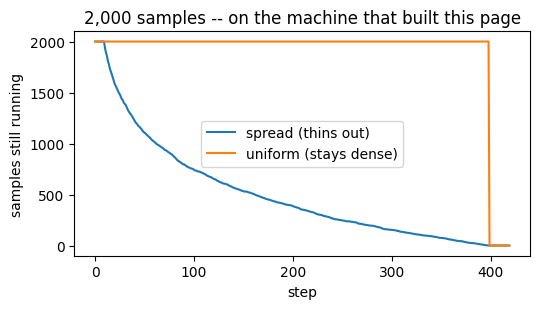

In [5]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(5.5, 3.2))
ax.plot(alive_spread, label="spread (thins out)")
ax.plot(alive_uniform, label="uniform (stays dense)")
ax.set_xlabel("step")
ax.set_ylabel("samples still running")
ax.set_title(f"{n:,} samples -- on the machine that built this page")
ax.legend()
fig.tight_layout()
plt.show()

## What just happened

- The *spread* batch thins fast: within a couple hundred steps, most of its
  2,000 lanes are already done, but `step_plain`'s launches still cover
  every sample until the very last one finishes.
- The *uniform* batch never thins: every sample is still running right up
  to the end, so there is nothing for compaction to skip.
- `step_compacting` (built with `Guard(active_set=True)`) is the same body,
  built so a launch can cover only the live samples once eagle's active-set
  map says who they are.

## When compaction pays, and when it costs (GPU, from the card)

<!-- stale-prose-gate:
benchmarks/perf_card/card_quadro-p2000.json: d37837fb31567858848e5f1830f19431
-->

```{list-table} Spread batch (thinning) vs. uniform batch (dense), GPU card, N = 1,000,000
:header-rows: 1

* - Batch size N
  - Thinning (spread-1000)
  - Dense (uniform)
* - 10^3
  - plain wins (`eagle_graph` 1.62 ms vs `eagle_graph_compact` 6.53 ms)
  - plain wins (1.32 ms vs 5.01 ms, 3.8x)
* - 10^4
  - plain still wins (7.61 ms vs 9.25 ms)
  - plain wins (7.74 ms vs 12.8 ms, 1.7x)
* - 10^5
  - compaction wins (66.6 ms vs 45.7 ms, 1.46x faster)
  - plain wins (72.3 ms vs 95.1 ms, 1.32x)
* - 10^6
  - compaction + reorder wins (625 ms plain, 415 ms compacted, 279 ms with reorder: 1.51x, then 1.49x)
  - plain wins (703 ms vs 862 ms, 1.23x)
```

The rule of thumb: compaction starts paying for itself once a thinning
batch reaches about 10^5 samples; below that, or on a batch that never
thins, the active-set bookkeeping costs more than it saves, and the plain
kernel is the better fit. The reorder (`eagle.until_done(..., reorder=theta)`)
is the same story one size up: it earns its keep from about 10^5 too.

In [6]:
# Functional check, not a timing claim -- the numbers above are the card's.
reorder_planes = dict(omega=xp.full(n, 3.0), zeta=0.1, nstop=nstop_spread, dt=0.05,
                       x=xp.zeros(n), v=xp.zeros(n), k=xp.zeros(n))
compacting = eagle.until_done(eagle.deploy(step_compacting), max_steps=500, every=16,
                              **reorder_planes)
report = compacting.run()
print("compacting:", report.done, "compactions:", report.compactions)

compacting: True compactions: 25


## On the CPU, you usually leave it off

On the CPU, eagle's automatic kernel (`steps="auto"`, the plain
`@hawk.kernel` decorator) now runs TILE by tile: a whole block of samples
advances together, with its state kept in cache, and a finished sample's
lane inside that tile is simply masked rather than dropped. See
{doc}`05_steps_per_launch` for the tile rule. That tiling already does
most of what the active-set map buys on the GPU, so the plain kernel —
`step_plain` here, or the default `@hawk.kernel` with no `Guard` — is the
one to reach for on the CPU; build the compacting kind when your data lives
on cupy arrays.

## Try this

Change `nstop_spread`'s upper end from 400 to 4000 and re-run: the gap
between the two curves above opens up earlier.

## Next

- {doc}`05_steps_per_launch` — the other knob this page didn't touch:
  how many steps one launch runs.
- deeper: {doc}`../../performance` ("What compaction adds"/"costs" and the
  reorder sections) for the full table, every N and both configurations.